# Starting Kit - FAIR UNIVERSE: HIGGSML UNCERTAINTY CHALLENGE

For Overview and Descriptions of the competition, please visit the [competition page](https://www.codabench.org/competitions/2977/)

`COLAB` determines whether this notebook is running on Google Colab.
For local setup check : [Local Setup](./pages/Local_setup.md)

In [1]:
COLAB = 'google.colab' in str(get_ipython())

In [2]:
if COLAB:
    # clone github repo
    !git clone --depth 1 https://github.com/FAIR-Universe/HEP-Challenge.git

    # move to the HEP starting kit folder
    %cd HEP-Challenge/

    # Install required packages
    # %pip install -r conda/requirements.txt 

### Dummy_Submission
By this point you should have a clone of the repo which contains `HiggsML_Dummy_Submission.zip` which you can submit to the Competition

### Imports

In [3]:
# Standard library imports
import datetime
import json
import os
from contextlib import closing
from sys import path
from zipfile import ZipFile, ZIP_DEFLATED

# Third-party imports
import numpy as np


### Directories

In [4]:

root_dir = os.getcwd()
print("Root directory is", root_dir)

# The directory of the input data
input_dir = os.path.join(root_dir, "input_data")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission") 

# The directory of the ingestion program 
program_dir = os.path.join(root_dir, "ingestion_program") 

# The directory of the scoring program
score_dir = os.path.join(root_dir, "scoring_program")
submission_dir = os.path.join(root_dir, "sample_submission")

# Add the directory to the path
path.append(program_dir) 
path.append(score_dir)
path.append(submission_dir)

Root directory is /sps/atlas/r/rchakkap/PhD/HEP-Challenge


In [5]:
from systematics import systematics # import the systematics function from the ingestion program

***
## Data
***

⚠️ Note:

By default the repository has a sample dataset at [input_data](./input_data/). This is a small sample data is for demonstration only to get a view of what the data looks like.

For Training and inference you may want to use the much Bigger public dataset. For this set `USE_PUBLIC_DATASET` to `True` and the code below uses the  `Neurips2024_public_dataset()` funtion in the `dataset` module to download and read the public dataset. else the code loads the small sample data for quick execution of this notebook


⚠️ Note:

If you have already downloaded the public_data from the competition website, make sure that it is placed in the right folder `HEP-Challenge/` so that you don't download it again. Setting `USE_PUBLIC_DATASET` to `True` will download the public_data if not found in the `HEP-Challenge` directory.

In [6]:
USE_PUBLIC_DATASET = True

`USE_PUBLIC_DATASET` determines whether to use a public dataset provided for the participants or use a small subset of the data for quick execution of this notebook

In [7]:
from datasets import Data # import the Data class from the ingestion program

if USE_PUBLIC_DATASET:
    from datasets import Neurips2024_public_dataset as public_dataset
    data = public_dataset()
else:
    data = Data(input_dir)

2025-10-22 14:44:00,836 - datasets             - INFO     - Total rows: 220099101
2025-10-22 14:44:00,836 - datasets             - INFO     - Test size: 66029730


The function loads the downloaded data in the public_data folder or downloads the data from codabench using `request` from zenodo in the absence of the downloaded data, 

In [8]:
# load train set
data.load_train_set(train_size=50000) # load the training set to memory, this may take a few seconds
data_vis = data.get_train_set()

print(data_vis.shape)


2025-10-22 14:44:10,504 - datasets             - INFO     - Selected train size: 50000
2025-10-22 14:48:12,228 - datasets             - INFO     - Data loaded successfully


(50000, 31)


***
## Visualize
***
The purpose of the `Dataset_visualise` class is to visulaise the training dataset,
data is the dictionary of different fields like dataframe, label, weights etc. upon initiallisation you will see a table of these fields

Initialisation you can give a list a columns of Data you are interested to have plots for. If no inputs are given then all the columns of the DataFrame are taken

In [9]:
import visualization as viz
 
train_visualize = viz.Dataset_visualise(
    data_set=data_vis,
    columns=[
        "PRI_met",
        "PRI_had_pt",
        "DER_mass_vis",
        "PRI_jet_leading_eta",
    ],
    name="Train Set",
)

The `examine_dataset` methods give you more general infomation as tables to give an idea of the general nature of the training data

In [10]:
# Show data summary
train_visualize.examine_dataset()


+---------------------+-------------------------+-------------------------------------+
| Key                 | Value                   | Type                                |
+=====================+=========================+=====================================+
| PRI_met             | Array of shape (50000,) | <class 'pandas.core.series.Series'> |
+---------------------+-------------------------+-------------------------------------+
| PRI_had_pt          | Array of shape (50000,) | <class 'pandas.core.series.Series'> |
+---------------------+-------------------------+-------------------------------------+
| DER_mass_vis        | Array of shape (50000,) | <class 'pandas.core.series.Series'> |
+---------------------+-------------------------+-------------------------------------+
| PRI_jet_leading_eta | Array of shape (50000,) | <class 'pandas.core.series.Series'> |
+---------------------+-------------------------+-------------------------------------+
+--------------------+---------

,PRI_met,PRI_had_pt,DER_mass_vis,PRI_jet_leading_eta
0,3.852000,25.952000,57.275307,-25.000
1,11.441000,30.688000,90.414101,-25.000
2,42.077000,24.412001,83.821045,3.537
3,5.090000,40.528000,72.205055,-25.000
4,44.391998,32.275002,44.896721,-0.012



[*] --- Description of all features



,PRI_met,PRI_had_pt,DER_mass_vis,PRI_jet_leading_eta
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,24.975723,43.155182,74.572487,-13.149580
std,27.997725,21.305498,25.786999,12.555107
min,0.037000,22.993999,18.376673,-25.000000
25%,9.693750,30.757999,61.499278,-25.000000
50%,16.914500,38.182999,70.695644,-25.000000
75%,28.880499,48.225249,82.026596,-0.160000
max,597.666992,498.959991,1000.957642,4.803000


In [11]:
from IPython.display import display

print("\n[*] --- Examples of all features\n")
display(data_vis.head())

print("\n[*] --- Description of all features\n")
display(data_vis.describe())


[*] --- Examples of all features



,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,...,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality
0,31.714001,1.648,2.608,25.952000,1.593,-0.665,-25.000000,-25.000,-25.000,-25.000000,...,10.711481,-25.000,-25.000000,-25.000000,3.010688,10.711481,57.666000,1.222025,1.410312,-25.000000
1,31.264999,-1.590,-0.935,30.688000,0.266,2.392,-25.000000,-25.000,-25.000,-25.000000,...,7.376070,-25.000,-25.000000,-25.000000,3.490526,7.376070,61.952999,1.018802,-1.412490,-25.000000
2,24.973000,-0.996,1.623,24.412001,1.432,0.002,80.306000,3.537,-2.193,54.120998,...,68.648003,5.105,848.453674,-5.546016,2.919388,25.055002,223.800995,1.022980,0.894482,0.547699
3,31.951000,1.494,-0.552,40.528000,1.331,2.569,-25.000000,-25.000,-25.000,-25.000000,...,3.525352,-25.000,-25.000000,-25.000000,3.125254,3.525352,72.479004,0.788369,-1.389855,-25.000000
4,25.129999,-0.611,0.881,32.275002,0.691,1.631,94.293999,-0.012,-1.721,-25.000000,...,97.810806,-25.000,-25.000000,-25.000000,1.502566,14.612669,151.699005,0.778621,1.412009,-25.000000



[*] --- Description of all features



,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,...,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,33.974270,-0.003363,0.017542,43.155182,0.001618,-0.018130,20.458088,-13.149580,-13.151315,-8.615425,...,41.842590,-18.919350,50.689121,-19.468332,2.735729,18.065891,127.261574,0.878801,0.265323,-19.350248
std,18.235386,1.222819,1.815323,21.305498,1.250847,1.815278,62.913666,12.555107,12.542118,33.830360,...,54.060059,11.407591,237.797852,10.542344,0.612884,16.202436,108.570107,0.502736,1.215411,10.573371
min,20.000000,-2.500000,-3.142000,22.993999,-2.636000,-3.142000,-25.000000,-25.000000,-25.000000,-25.000000,...,0.044402,-25.000000,-25.000000,-25.000000,0.597506,0.044402,43.379002,0.062899,-1.414214,-25.000000
25%,23.959999,-0.947000,-1.560000,30.757999,-0.984000,-1.598000,-25.000000,-25.000000,-25.000000,-25.000000,...,10.897137,-25.000000,-25.000000,-25.000000,2.506135,8.477187,64.501749,0.586448,-1.331848,-25.000000
50%,29.007999,-0.006000,0.038000,38.182999,0.004000,-0.040000,-25.000000,-25.000000,-25.000000,-25.000000,...,21.568191,-25.000000,-25.000000,-25.000000,2.955447,14.447876,85.346001,0.774810,0.974545,-25.000000
75%,37.078500,0.951000,1.587000,48.225249,0.986000,1.548000,47.178501,-0.160000,-0.207000,-25.000000,...,49.011813,-25.000000,-25.000000,-25.000000,3.126998,22.627847,144.060246,1.023536,1.384899,-25.000000
max,607.010010,2.500000,3.142000,498.959991,2.656000,3.142000,1000.859985,4.803000,3.141000,568.343018,...,905.179810,9.412001,4437.017090,20.107859,4.846869,353.027222,1732.585938,10.491792,1.414214,1.000000


### Histograms
The `histogram_dataset` method gives a set of histograms (for the columns defined before)
It provides insights into the range and frequency of values for a specific feature. By analyzing the histogram, we can identify any patterns or anomalies in the data. This helps in understanding the underlying distribution and making informed decisions during the data analysis process

[*] --- PRI_met histogram
[*] --- PRI_had_pt histogram
[*] --- DER_mass_vis histogram
[*] --- PRI_jet_leading_eta histogram


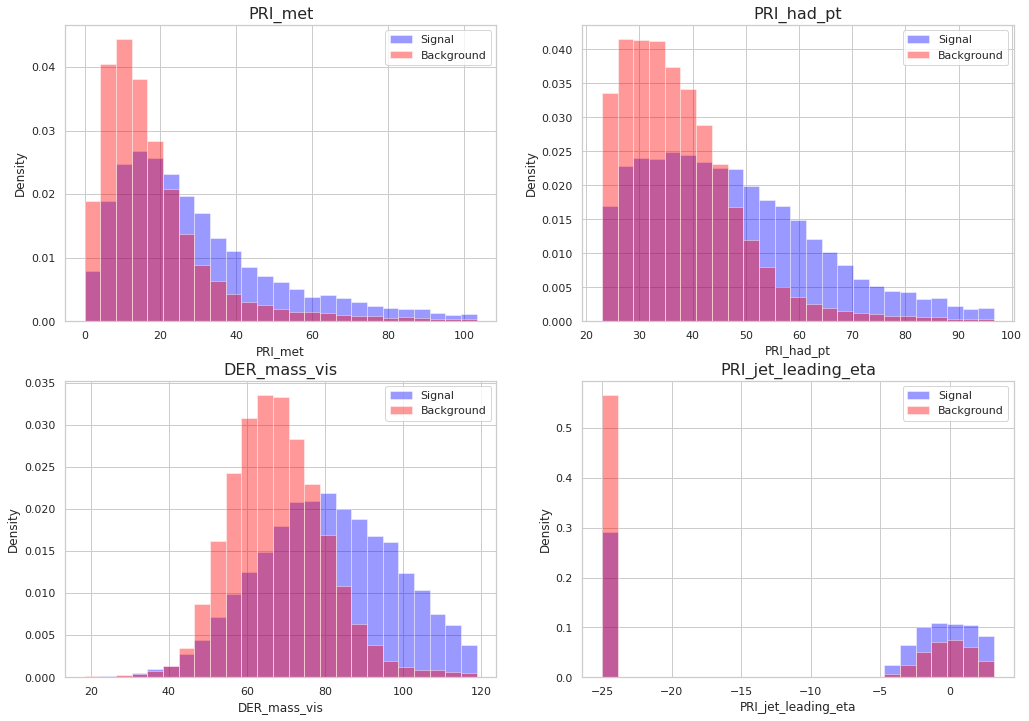

In [12]:
# Show data summary
train_visualize.histogram_dataset()

### Stacked Histogram

The stacked histogram is a visualization technique used to display the distribution of categories within a dataset for a perticular feature. It is particularly useful when comparing the distribution of different groups or classes.

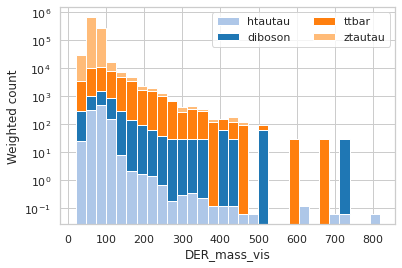

In [13]:
train_visualize.stacked_histogram("DER_mass_vis",mu_hat=2.5,y_scale="log")

/cvmfs/sft.cern.ch/lcg/views/LCG_107/x86_64-el9-gcc13-opt/lib/python3.11/site-packages/seaborn/axisgrid.py:186: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  figlegend = self._figure.legend(handles, labels, **kwargs)


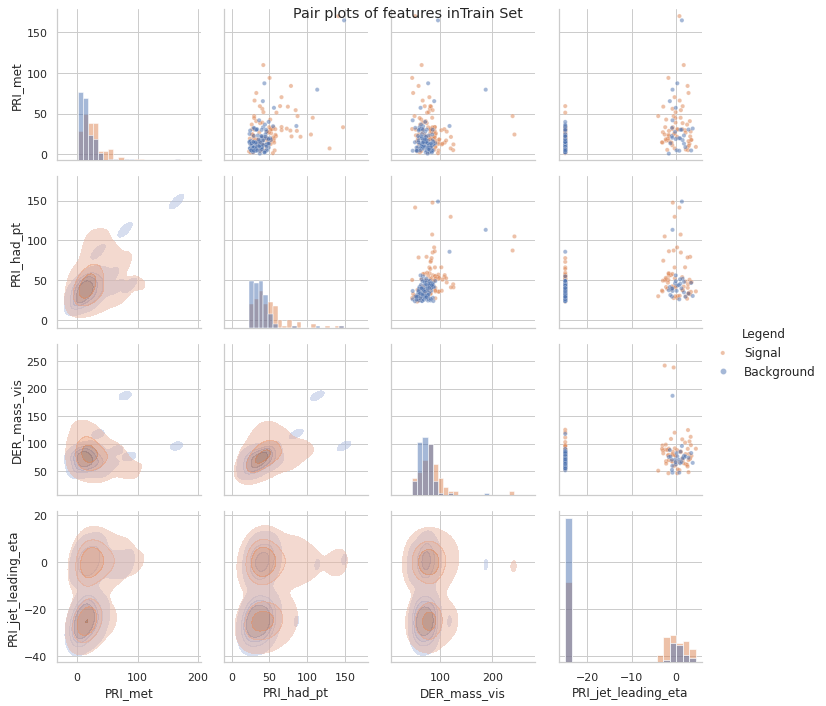

In [14]:
train_visualize.pair_plots(sample_size=100)

In [15]:
""" 
when No systematics parameters are passed, and dopostprocess is True .
This mean derived quantities are calculated and Post process cuts are applied
"""
syst_train_data = systematics(data_vis,tes=0.9, dopostprocess=True) 

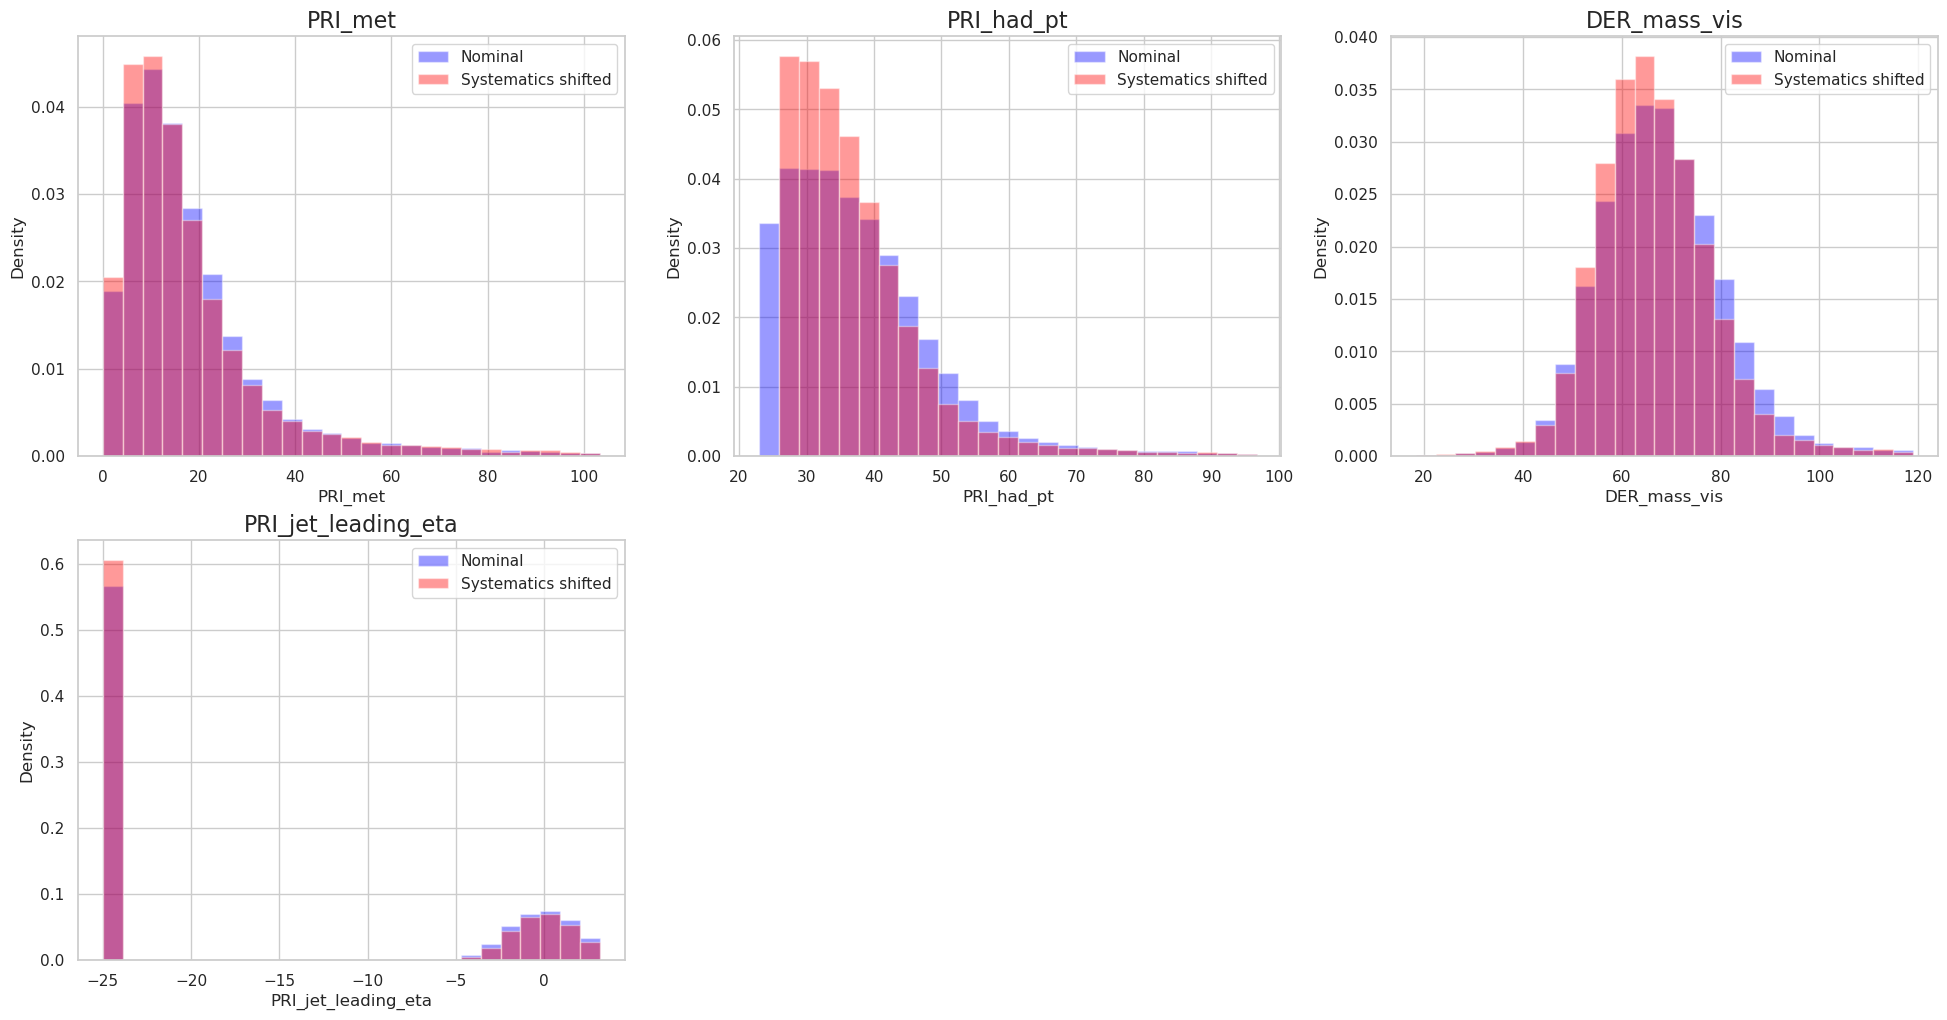

In [16]:
train_visualize.histogram_syst(syst_train_data,syst_train_data['weights'])

For event vise plots we want sytematics plots without without post process cuts

In [17]:
data_vis = data.get_train_set()
# when No systematics parameters are passed, and dopostprocess is false .This mean only derived quantities are calculated
data_vis = systematics(data_vis, dopostprocess=False) 

In [18]:
train_visualize = viz.Dataset_visualise(
    data_set=data_vis,
    columns=[
        "PRI_met",
        "PRI_had_pt",
        "DER_mass_vis",
        "DER_mass_transverse_met_lep",
        "DER_deltar_had_lep",

    ],
    name="Train Set",
)

In [19]:
syst_train_data = systematics(data_vis,tes = 0.9, dopostprocess=False)  # you can use other systematics like jes, softmet, etc.

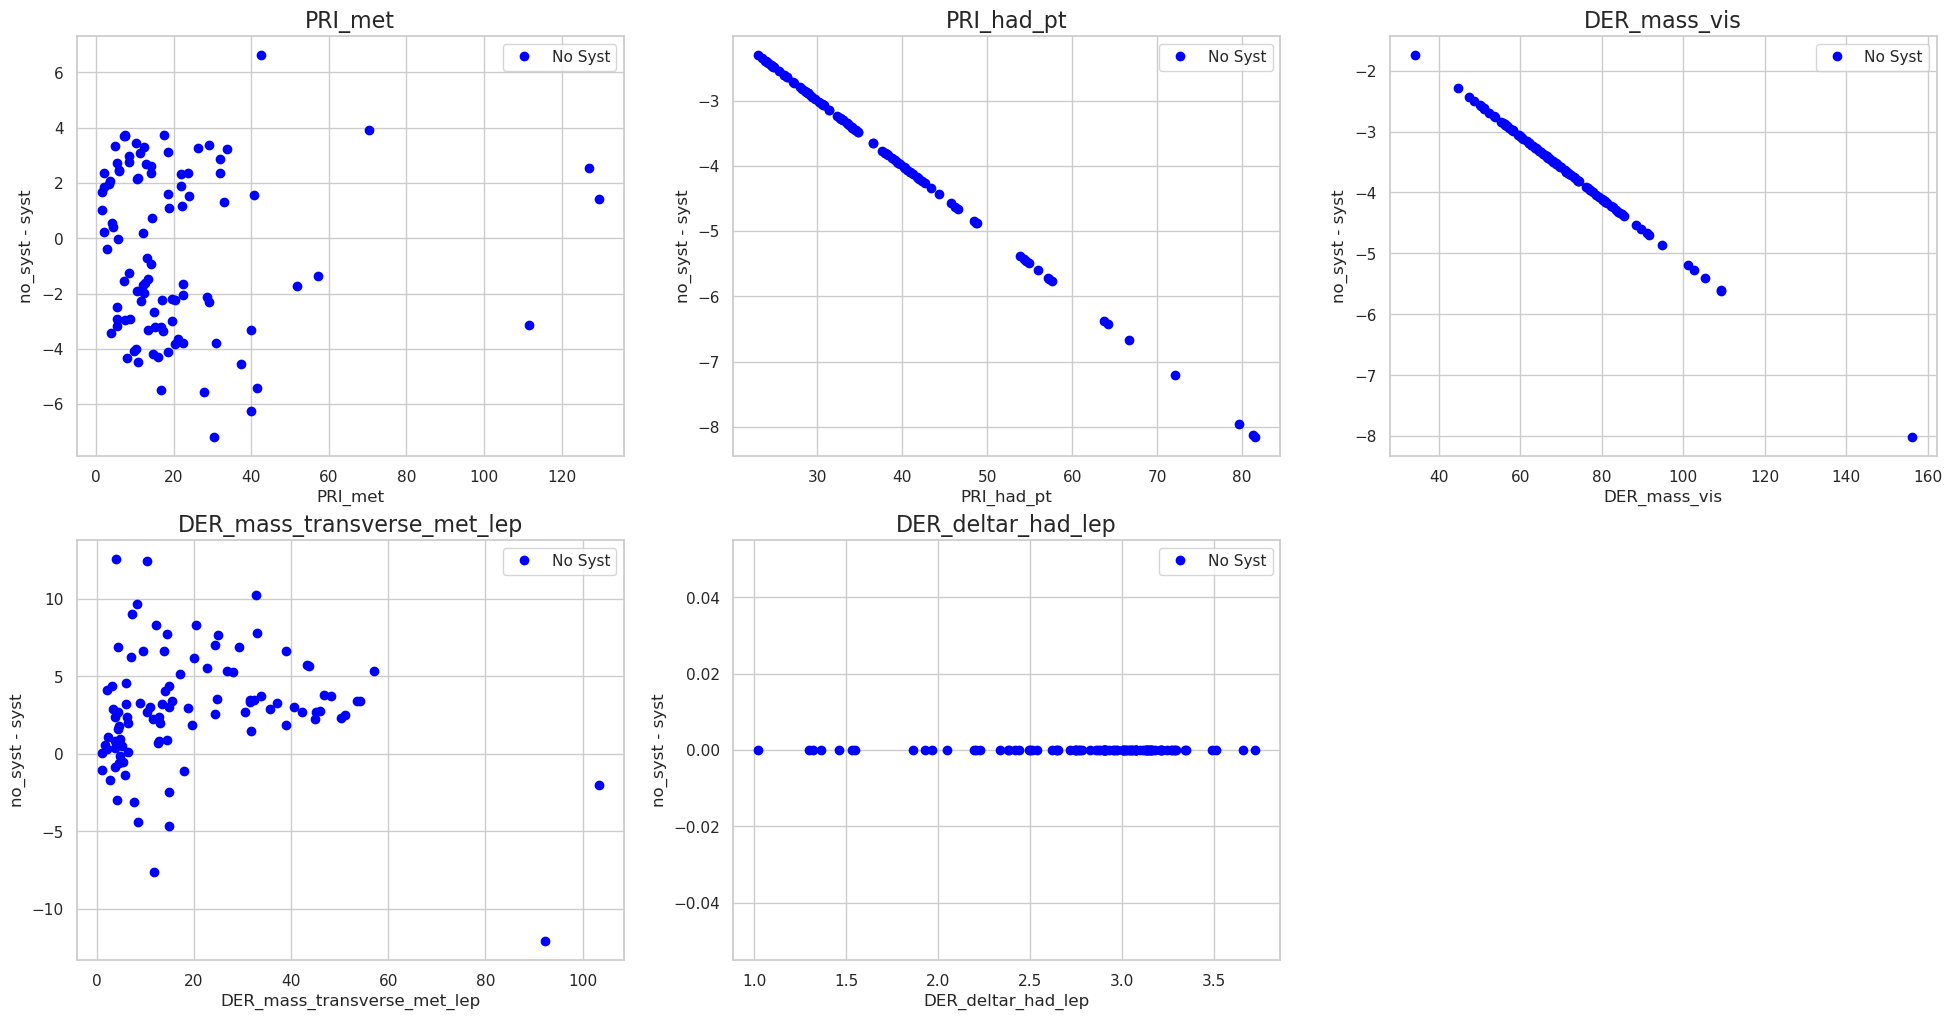

In [20]:
train_visualize.event_vise_syst(syst_train_data)

***
### Program
***


In [21]:

from ingestion import Ingestion

ingestion = Ingestion(data)


***
## MODEL
***
For the competition model should be defined as a class and saved a file called model.py.


***
## The Model Class
***
We import a class named `Model` from the submission file (`model.py`). This `Model` class has the following methods:
- `init`: receives train set and systematics class as input
- `fit`: can be used for training
- `predict`: receives one test set and outputs a dictionary with the following keys
    - `mu_hat` : predicted mu $\hat{\mu}$
    - `delta_mu_hat`: $\Delta{\hat{\mu}}$ bound for $\mu$
    - `p16`: 16th percentile
    - `p84`: 84th percentile

In this example code, the `Model` class implements an XGBoost model which is trained to predicts the class label. The notebook cells with the benchmark model has "%%writefile" in the very top. This will make a copy of the cell into various python files in `HEP-Challenge/sample_submission. Thoes modules are then imported back into this notebook.

#### ⚠️ Note:
In real setting i.e. the challenge itself, the submitted model is initialized once with train set and systematics class and the `predict` is called multiple times, each time with a different test sets. 

In [22]:
%%writefile sample_submission/model.py
#!/usr/bin/env python3


from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from LHC_statistics import compute_mu, calculate_saved_info
import numpy as np

class Model:

    def __init__(self, get_train_set=None, systematics=None):

        self.get_train_set = get_train_set
        self.systematics = systematics
                
        self.model = XGBClassifier(
            n_estimators=300, eval_metric="logloss"
        )
        self.name = "model_XGB"
        self.scaler = StandardScaler()

        self.N_events_total = 15_000_000

        

    def fit(self):
        """
        Trains the model.

        Params:
            None

        Functionality:
            This function can be used to train a model. If `re_train` is True, it balances the dataset,
            fits the model using the balanced dataset, and saves the model.The saved information is used
            to compute the train results.

        Returns:
            None
        """

        from visualization import stacked_histogram, Dataset_visualise, roc_curve_wrapper
        
        try :
            data_df = self.get_train_set(train_size=self.N_events_total)
        except Exception as e :
            print(e)
            data_df = self.get_train_set(train_size=self.N_events_total)
        
        #Divide the dataset
        
        training_df, temp_df = train_test_split(
            data_df, test_size= (2 / 3) , random_state=42, reweight=True
        )
        
        holdout_df, test_df = train_test_split(
            temp_df, test_size=(1/2), random_state=42, reweight=True
        )
        
        print("Training set size: ", training_df.shape)
        print("Holdout set size: ", holdout_df.shape)
        print("Test set size: ", test_df.shape)
        
        train_vis = Dataset_visualise(
            data_set=training_df,
            name="Training Set",
            columns=[
                "PRI_met",
                "PRI_had_pt",
                "DER_mass_vis"],
        )
        
        train_vis.examine_dataset()

                
        training_df = self.systematics(training_df)
        
        training_set = {
            "labels": training_df.pop("labels"),
            "weights": training_df.pop("weights"),
            "detailed_labels": training_df.pop("detailed_labels"),
            "data": training_df
        }
        
        
        balanced_set = balance_set(training_set)
                                
        self.scaler.fit(balanced_set["data"])
        
        X_train_data = self.scaler.transform(balanced_set["data"])
        self.model.fit(X_train_data,balanced_set["labels"], balanced_set["weights"])
        
        
        del balanced_set
        
        holdout_df = self.systematics(holdout_df)

        
        holdout_set = {
            "labels": holdout_df.pop("labels"),
            "weights": holdout_df.pop("weights"),
            "detailed_labels": holdout_df.pop("detailed_labels"),
            "data": holdout_df
        }
                
        
        X_holdout = self.scaler.transform(holdout_set["data"])

        holdout_score = self.model.predict_proba(X_holdout)[:, 1]

        self.saved_info = calculate_saved_info(holdout_score, holdout_set)


        holdout_results = compute_mu(
            holdout_score, holdout_set["weights"], self.saved_info
        )
        
        roc_curve_wrapper(holdout_score, holdout_set["labels"],holdout_set["weights"], plot_label="Holdout ROC curve")

        
        stacked_histogram(detailed_label=holdout_set["detailed_labels"],
            field=holdout_score,
            weights=holdout_set["weights"],
            target=holdout_set["labels"],
            y_scale="linear",
            plot_label="Holdout Score No weights",
            weighted=False
        )
        
        stacked_histogram(detailed_label=holdout_set["detailed_labels"],
            field=holdout_score,
            weights=holdout_set["weights"],
            target=holdout_set["labels"],
            y_scale="log",
            plot_label="Holdout Score",
        )

            
        print("Holdout Results: ")
        for key in holdout_results.keys():
            print("\t", key, " : ", holdout_results[key])

        test_vis = Dataset_visualise(
            data_set=test_df,
            name="Training Set",
            columns=[
                "PRI_met",
                "PRI_had_pt",
                "DER_mass_vis"],
        )
        
        test_vis.examine_dataset()    
        bootstraped_test_df = test_df.copy()

        test_df = self.systematics(test_df)

        test_set ={
            "labels": test_df.pop("labels"),
            "weights": test_df.pop("weights"),
            "detailed_labels": test_df.pop("detailed_labels"),
            "data": test_df
        }

        random_state = np.random.RandomState(42)
        mu_test =random_state.uniform(0.1, 3)
                        
        test_set["weights"][test_set["labels"] == 1] *= mu_test
                
        X_test =  self.scaler.transform(test_set["data"])
        
        test_score = self.model.predict_proba(X_test)[:, 1]
        test_results = compute_mu(
            test_score, test_set["weights"], self.saved_info
        )

        mu_test_hat = test_results["mu_hat"]
        
        print("Test Results: ")
        for key in test_results.keys():
            print("\t", key, " : ", test_results[key])
        
        stacked_histogram(detailed_label=holdout_set["detailed_labels"],
            field=holdout_score,
            weights=holdout_set["weights"],
            target=holdout_set["labels"],
            mu_hat=mu_test_hat,
            pseudo_field=test_score,
            pseudo_weight=test_set["weights"],
            y_scale="log",
            plot_label="BDT Score",
            seperate_signal=True,
            path_to_figures="./"
        )
                  

    def predict(self, test_set):
        """
        Predicts the values for the test set.

        Parameters:
            test_set (dict): A dictionary containing the test data, and weights.

        Returns:
            dict: A dictionary with the following keys:
            * 'mu_hat': The predicted value of mu.
            * 'delta_mu_hat': The uncertainty in the predicted value of mu.
            * 'p16': The lower bound of the 16th percentile of mu.
            * 'p84': The upper bound of the 84th percentile of mu.
        """

        test_data = test_set["data"]
        test_weights = test_set["weights"]

        test_data = self.scaler.transform(test_data)
        predictions = self.model.predict_proba(test_data)[:, 1]
    
        result_mu_cal = compute_mu(predictions, test_weights, self.saved_info)

        print("Test Results: ", result_mu_cal)

        result = {
            "mu_hat": result_mu_cal["mu_hat"],
            "delta_mu_hat": result_mu_cal["del_mu_tot"],
            "p16": result_mu_cal["mu_hat"] - result_mu_cal["del_mu_tot"],
            "p84": result_mu_cal["mu_hat"] + result_mu_cal["del_mu_tot"],
        }

        return result



Overwriting sample_submission/model.py


In [23]:
%%writefile -a sample_submission/model.py


from sklearn.model_selection import train_test_split as sk_train_test_split
import pandas as pd

def train_test_split(data_set, test_size=0.2, random_state=42, reweight=False):

    train_set, test_set = sk_train_test_split(
        data_set, test_size=test_size, random_state=random_state
    )


    if reweight is True:
        signal_weight = np.sum(data_set["weights"][data_set["labels"] == 1])
        background_weight = np.sum(data_set["weights"][data_set["labels"] == 0])
        signal_weight_train = np.sum(train_set["weights"][train_set["labels"] == 1])
        background_weight_train = np.sum(train_set["weights"][train_set["labels"] == 0])
        signal_weight_test = np.sum(test_set["weights"][test_set["labels"] == 1])
        background_weight_test = np.sum(test_set["weights"][test_set["labels"] == 0])

        train_set["weights"][train_set["labels"] == 1] = train_set["weights"][
            train_set["labels"] == 1
        ] * (signal_weight / signal_weight_train)
        test_set["weights"][test_set["labels"] == 1] = test_set["weights"][
            test_set["labels"] == 1
        ] * (signal_weight / signal_weight_test)

        train_set["weights"][train_set["labels"] == 0] = train_set["weights"][
            train_set["labels"] == 0
        ] * (background_weight / background_weight_train)
        test_set["weights"][test_set["labels"] == 0] = test_set["weights"][
            test_set["labels"] == 0
        ] * (background_weight / background_weight_test)

    return train_set, test_set


Appending to sample_submission/model.py


In [24]:
%%writefile -a sample_submission/model.py


def balance_set(train_set):
    """
    Balances the training set by equalizing the number of background and signal events.

    Args:
        train_set (dict): A dictionary containing the training data, labels, and weights.

    Returns:
        dict: A dictionary with the balanced training set.
    """
    balanced_set = train_set.copy()

    weights_train = train_set["weights"].copy()
    train_labels = train_set["labels"].copy()
    class_weights_train = (
        weights_train[train_labels == 0].sum(),
        weights_train[train_labels == 1].sum(),
    )

    for i in range(len(class_weights_train)):  # loop on B then S target
        # training dataset: equalize number of background and signal
        weights_train[train_labels == i] *= (
            max(class_weights_train) / class_weights_train[i]
        )
        # test dataset : increase test weight to compensate for sampling

    balanced_set["weights"] = weights_train

    return balanced_set


Appending to sample_submission/model.py


In [25]:
%%writefile sample_submission/LHC_statistics.py

import numpy as np

def calculate_saved_info(score, train_set):

    print("score shape before threshold", score.shape)

    label = train_set["labels"]

    print("score shape after threshold", score.shape)
    
    signal_weights = train_set["weights"][label == 1]
    background_weights = train_set["weights"][label == 0]
    signal_score = score[label == 1]
    background_score = score[label == 0]

    gamma = np.sum(signal_weights[signal_score > 0.5])  # signal efficiency at 0.5 threshold

    beta = np.sum(
        background_weights[background_score > 0.5]
    )  # background efficiency at 0.5 threshold

    saved_info = {"beta": beta, "gamma": gamma}

    print("saved_info", saved_info)

    return saved_info

Overwriting sample_submission/LHC_statistics.py


In [26]:
%%writefile -a sample_submission/LHC_statistics.py


def compute_mu(score, weight, saved_info):

    weight_above_threshold = weight[score > 0.5]
    score = score[score > 0.5]
    N_events = np.sum(weight_above_threshold)

    mu = (N_events - saved_info["beta"]) / saved_info["gamma"]
    del_mu_stat = (
        np.sqrt(saved_info["beta"] + saved_info["gamma"]) / saved_info["gamma"]
    )
    del_mu_sys = abs(0.1 * mu)
    del_mu_tot = (1 / 2) * np.sqrt(del_mu_stat**2 + del_mu_sys**2)

    return {
        "mu_hat": mu,
        "del_mu_stat": del_mu_stat,
        "del_mu_sys": del_mu_sys,
        "del_mu_tot": del_mu_tot,
    }

Appending to sample_submission/LHC_statistics.py


In [27]:
from model import Model 
# import the Model class from the model.py file which was saved from the previous cell

# initialize submission
ingestion.init_submission(Model)

2025-10-22 14:48:24,496 - ingestion            - INFO     - Initializing Submmited Model


The `fit_submission` then calls fit method of the model and concludes the training phase of the model

2025-10-22 14:48:24,505 - ingestion            - INFO     - Fitting Submmited Model


2025-10-22 14:48:37,699 - datasets             - INFO     - Selected train size: 15000000
2025-10-22 14:58:47,446 - datasets             - INFO     - Data loaded successfully
/sps/atlas/r/rchakkap/PhD/HEP-Challenge/sample_submission/model.py:250: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

Training set size:  (5000000, 31)
Holdout set size:  (5000000, 31)
Test set size:  (5000000, 31)

+--------------+---------------------------+-------------------------------------+
| Key          | Value                     | Type                                |
+==============+===========================+=====================================+
| PRI_met      | Array of shape (5000000,) | <class 'pandas.core.series.Series'> |
+--------------+---------------------------+-------------------------------------+
| PRI_had_pt   | Array of shape (5000000,) | <class 'pandas.core.series.Series'> |
+--------------+---------------------------+-------------------------------------+
| DER_mass_vis | Array of shape (5000000,) | <class 'pandas.core.series.Series'> |
+--------------+---------------------------+-------------------------------------+
+--------------------+--------------+
| Key                | Value        |
+====================+==============+
| Dataset name       | Training Set |
+--

,PRI_met,PRI_had_pt,DER_mass_vis
1973040,67.711998,46.845001,75.371887
2124368,13.179000,49.549999,85.020309
2269680,7.732000,35.037998,68.229782
1434410,7.392000,38.527000,87.336441
9736478,20.909000,39.694000,109.335182



[*] --- Description of all features



,PRI_met,PRI_had_pt,DER_mass_vis
count,5.000000e+06,5.000000e+06,5.000000e+06
mean,2.492368e+01,4.305402e+01,7.454839e+01
std,2.787575e+01,2.111566e+01,2.488956e+01
min,9.000000e-03,2.287800e+01,1.373778e+01
25%,9.727000e+00,3.075975e+01,6.156971e+01
50%,1.687900e+01,3.818000e+01,7.072663e+01
75%,2.888200e+01,4.813800e+01,8.212297e+01
max,1.271810e+03,9.021350e+02,1.900269e+03


/sps/atlas/r/rchakkap/PhD/HEP-Challenge/ingestion_program/derived_quantities.py:282: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-7.58271517e-02  3.60921729e-02 -4.88089962e-01 -8.27986479e-01
  5.45086797e-01  1.98767332e-01  1.81095289e-01 -1.53293119e-01
 -2.02489949e-01 -9.65065336e-01  7.29306190e-01  1.61391090e-01
  8.40008893e-02  3.40934308e-02  5.40557834e-01  8.58890817e-01
 -9.53622037e-02  3.07057897e-01  8.45396622e-01  2.49438103e-01
 -7.98149968e-02  5.50719521e-02  5.74587459e-01 -3.88404875e-01
 -3.28674763e-01 -6.96362831e-02 -1.47361387e-01  7.40322081e-02
  3.09911604e-01  2.09997271e-03  9.78175840e-01  9.18036602e-01
 -4.81968527e-01  3.60921729e-02  6.20601300e-02  6.70496536e-02
  1.83061832e-01  1.01922702e-01  3.70914307e-02  6.25755715e-01
 -1.58232140e-01 -4.87216936e-01  1.24773953e-01 -3.90017703e-03
  9.18036696e-01 -9.07749499e-02  6.28870830e-01 -1.06696626e-01
  2.41

score shape before threshold (4586548,)
score shape after threshold (4586548,)
saved_info {'beta': 137143.86, 'gamma': 746.5165}


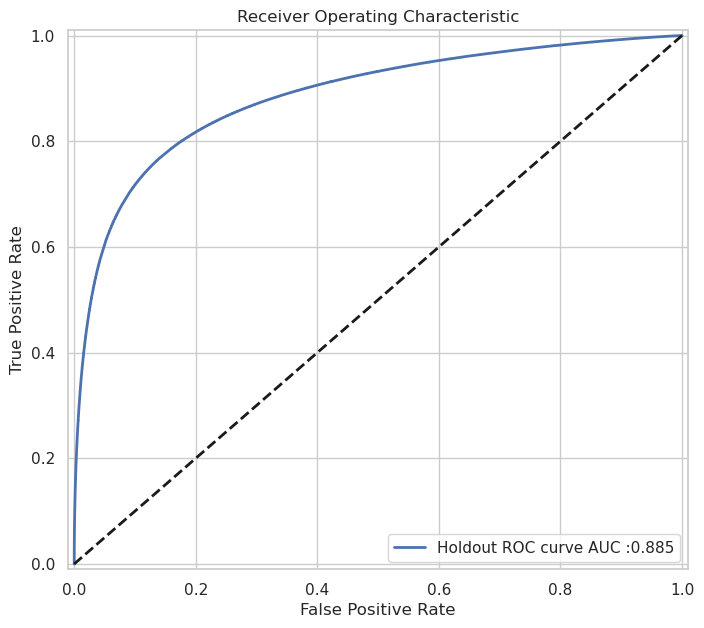

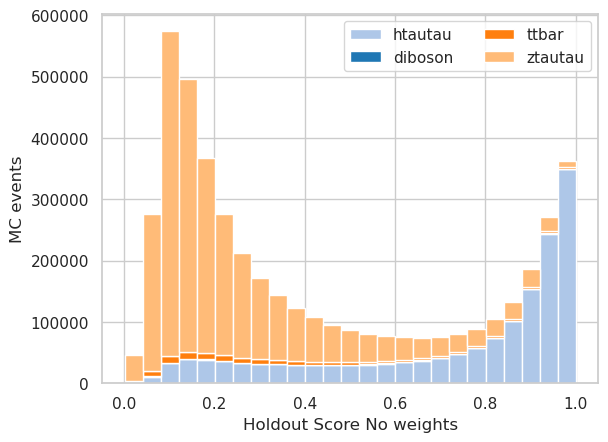

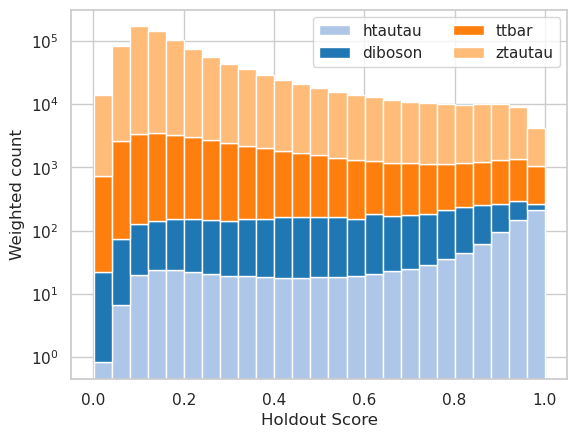

Holdout Results: 
	 mu_hat  :  1.0001035
	 del_mu_stat  :  0.49742496
	 del_mu_sys  :  0.10001034736633302
	 del_mu_tot  :  0.25368960391936013

+--------------+---------------------------+-------------------------------------+
| Key          | Value                     | Type                                |
+==============+===========================+=====================================+
| PRI_met      | Array of shape (5000000,) | <class 'pandas.core.series.Series'> |
+--------------+---------------------------+-------------------------------------+
| PRI_had_pt   | Array of shape (5000000,) | <class 'pandas.core.series.Series'> |
+--------------+---------------------------+-------------------------------------+
| DER_mass_vis | Array of shape (5000000,) | <class 'pandas.core.series.Series'> |
+--------------+---------------------------+-------------------------------------+
+--------------------+--------------+
| Key                | Value        |
+====================+==========

,PRI_met,PRI_had_pt,DER_mass_vis
6779385,23.878,31.723000,61.703995
13782708,12.549,44.070000,82.022667
10928068,5.511,37.354000,77.467140
14477873,7.393,33.867001,61.052010
1447713,6.902,32.178001,64.147766



[*] --- Description of all features



,PRI_met,PRI_had_pt,DER_mass_vis
count,5.000000e+06,5.000000e+06,5.000000e+06
mean,2.489515e+01,4.305952e+01,7.455823e+01
std,2.781623e+01,2.124814e+01,2.495397e+01
min,1.000000e-03,2.286500e+01,1.332951e+01
25%,9.715000e+00,3.075300e+01,6.156602e+01
50%,1.684600e+01,3.816300e+01,7.072634e+01
75%,2.884700e+01,4.811500e+01,8.214407e+01
max,1.100570e+03,1.288690e+03,1.829891e+03


/sps/atlas/r/rchakkap/PhD/HEP-Challenge/ingestion_program/derived_quantities.py:282: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.05806741  0.42421953 -0.45350369 -0.03689163 -0.15230495  0.19876732
  0.16730942  0.18109525  0.09794278  0.05507207  0.53042347 -0.01089982
  0.15645441 -0.08878293 -0.07881816 -0.7165893  -0.22708692 -0.23274586
 -0.42403852  0.24750084  0.06904503 -0.96102676  0.07203758  0.31750768
 -0.01689916  0.09435211  0.13369851 -0.15526926  0.18422692  0.00210009
  0.04508473 -0.02289794 -0.36152231  0.21442205 -0.53279504 -0.10371325
  0.01709925  0.54004677 -0.54207135  0.8968043   0.01609931 -0.25311624
  0.07702366 -0.23469033  0.06605186 -0.02589713  0.05007903 -0.87132694
 -0.99312953  0.02930315  0.11583935  0.30134222 -0.05886597  0.00509997
  0.28987852  0.11583929 -0.17400966 -0.96108412 -0.00689994  0.70063377
 -0.15329318 -0.04088873 -0.43397478 -0.4436727   0.4689

Test Results: 
	 mu_hat  :  1.4267620852816394
	 del_mu_stat  :  0.49742496
	 del_mu_sys  :  0.14267620852816396
	 del_mu_tot  :  0.2587412276033164


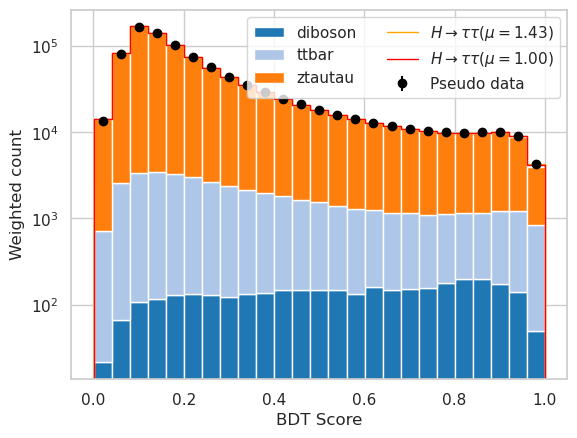

In [28]:

# fit submission
ingestion.fit_submission()

In [29]:
# load test sets
data.load_test_set() # load the test set to memory, this may take a few seconds

2025-10-22 16:28:58,174 - datasets             - INFO     - Data loaded successfully
2025-10-22 16:29:29,688 - datasets             - INFO     - Test data loaded successfully


### TEST SETTINGS

Here you can set the test settings. This will determine which all systematics are applied and how many pseudo experiments are run

⚠️ Note: As you can see by default *tes* or *Tau-hadron Energy scale systematics* is applied, when running stat-only method turn this to `False` to get meaningfull results.

In [30]:
TEST_SETTINGS = {
"systematics": {  # Systematics to use
    "tes": True, # tau energy scale
    "jes": False, # jet energy scale
    "soft_met": False, # soft term in MET
    "ttbar_scale": False, # ttbar scale factor
    "diboson_scale": False, # diboson scale factor
    "bkg_scale": False, # Background scale factor
    },
"num_pseudo_experiments" : 4 , # Number of pseudo-experiments to run per set
"num_of_sets" : 3, # Number of sets of pseudo-experiments to run
} 


In [31]:
test_settings = TEST_SETTINGS.copy()

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
test_settings[ "ground_truth_mus"] = (np.random.uniform(0.1, 3, test_settings["num_of_sets"])).tolist()

random_settings_file = os.path.join(output_dir, "random_mu.json")
with open(random_settings_file, "w") as f:
    json.dump(test_settings, f)


Next is the prediction phase this is where the pseudo experiments are defined and the model is **repeatedly** called to Evalute each pseudo dataset. 

**⚠️ Note: In the Real Challenge the prediction step is parallelised.**

In [32]:

# predict submission
ingestion.predict_submission(test_settings)

2025-10-22 16:29:30,052 - ingestion            - INFO     - Calling predict method of submitted model with seed: 31415


Test Results:  {'mu_hat': -0.7807722816735216, 'del_mu_stat': 0.49742496, 'del_mu_sys': 0.07807722816735217, 'del_mu_tot': 0.25175764364017306}
Test Results:  {'mu_hat': -11.541418859046322, 'del_mu_stat': 0.49742496, 'del_mu_sys': 1.1541418859046322, 'del_mu_tot': 0.6283858455929393}
Test Results:  {'mu_hat': 9.620873513583518, 'del_mu_stat': 0.49742496, 'del_mu_sys': 0.9620873513583519, 'del_mu_tot': 0.5415357011800888}
Test Results:  {'mu_hat': 9.051562571795463, 'del_mu_stat': 0.49742496, 'del_mu_sys': 0.9051562571795464, 'del_mu_tot': 0.5164153950256513}
Test Results:  {'mu_hat': 13.816360265772191, 'del_mu_stat': 0.49742496, 'del_mu_sys': 1.3816360265772192, 'del_mu_tot': 0.7342257317921375}
Test Results:  {'mu_hat': -4.873113286761771, 'del_mu_stat': 0.49742496, 'del_mu_sys': 0.4873113286761771, 'del_mu_tot': 0.3481752152375488}
Test Results:  {'mu_hat': 7.389174621774345, 'del_mu_stat': 0.49742496, 'del_mu_sys': 0.7389174621774345, 'del_mu_tot': 0.4453736091410932}
Test Results

The Last step combines the result from all the pseudo experiments and prepare it for scoring.

In [33]:
ingestion.compute_result()

2025-10-22 16:30:30,978 - ingestion            - INFO     - Computing Ingestion Result


In [34]:

# save result
!rm -rf $output_dir/*
ingestion.save_result(output_dir)

***
# Score
***
1. Compute Scores
2. Visualize Scores


In [35]:
from score import Scoring

In [36]:
# Initialize Score
score = Scoring()

In [37]:
score.load_ingestion_results(output_dir)

2025-10-22 16:30:32,249 - score                - INFO     - Read ingestion results from /sps/atlas/r/rchakkap/PhD/HEP-Challenge/sample_result_submission


The next stage computes the score the submitted model by evaluting the results from ingestion.

2025-10-22 16:30:32,294 - score                - INFO     - Computing scores


------------------
Set 0
------------------
MAE (avg): 15.661113597933214
RMSE (avg): 86.8522936147019
Interval: 0.9918618600235309
Coverage: 0.0
Quantiles Score: -0.5580934725818861
------------------
Set 1
------------------
MAE (avg): 18.609114540766114
RMSE (avg): 104.3476614261311
Interval: 1.1356277568570439
Coverage: 0.0
Quantiles Score: -0.6933229815062855
------------------
Set 2
------------------
MAE (avg): 10.092986610874487
RMSE (avg): 35.489740082397425
Interval: 0.7593112154228316
Coverage: 0.0
Quantiles Score: -0.29122977542482087


Overall Score
[*] --- RMSE: 75.563
[*] --- MAE: 14.788
[*] --- Interval: 0.962
[*] --- Coverage: 0.0
[*] --- Quantiles score: -4.475
[*] --- Ingestion duration: None
[✔]


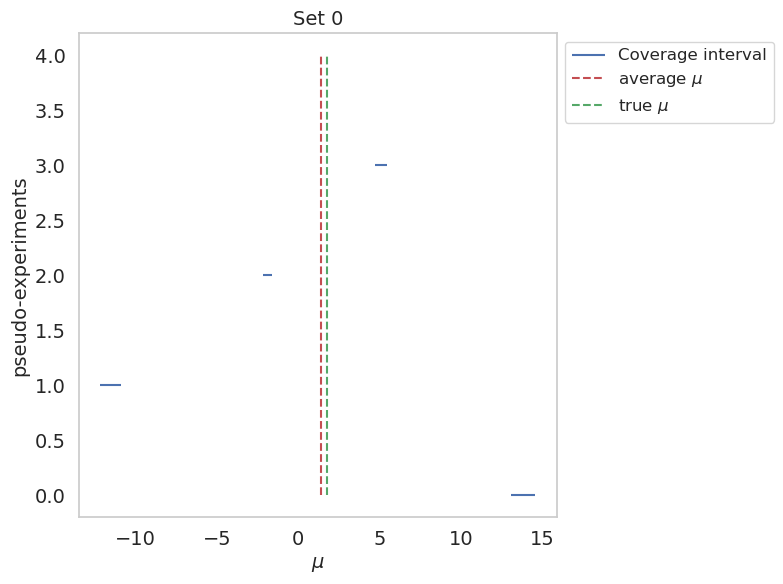

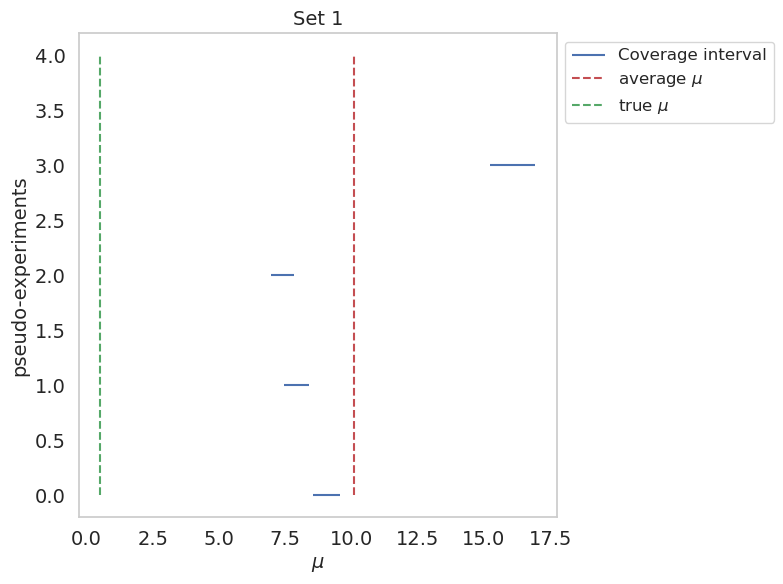

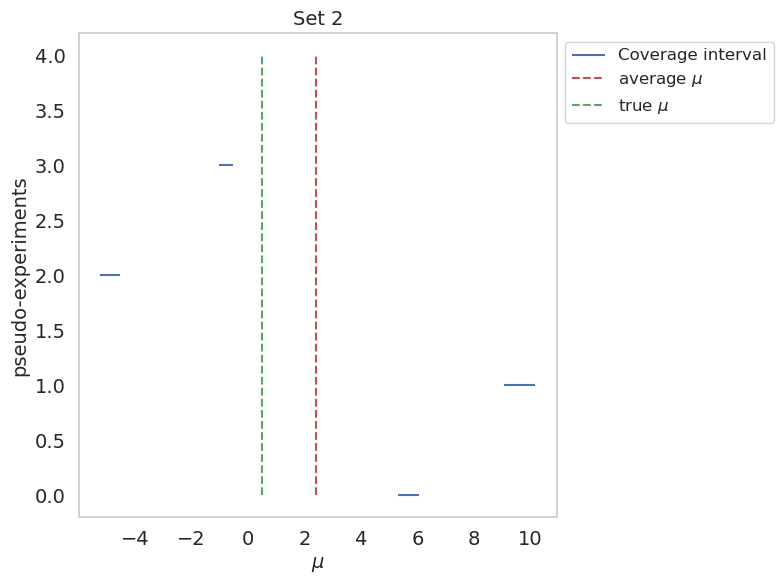

In [38]:
# Compute Score
score.compute_scores(test_settings)

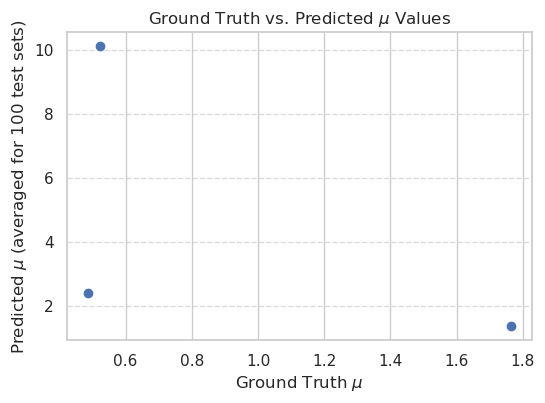

In [39]:
# Visualize scatter plot of ground truth mu and predicted mu
viz.visualize_scatter(ingestion_result_dict=ingestion.results_dict, 
                  ground_truth_mus=test_settings["ground_truth_mus"])

***
# Submission
***

### **Prepare the submission**

In [40]:
def zipdir(archivename, basedir):
    '''Zip directory, from J.F. Sebastian http://stackoverflow.com/'''
    assert os.path.isdir(basedir)
    with closing(ZipFile(archivename, "w", ZIP_DEFLATED)) as z:
        for root, dirs, files in os.walk(basedir):
            # NOTE: ignore empty directories
            for fn in files:
                if fn[-4:] != '.zip' and fn != '.DS_Store':
                    absfn = os.path.join(root, fn)
                    zfn = absfn[len(basedir):]  # XXX: relative path
                    z.write(absfn, zfn)

In [41]:
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
code_submission = 'Submission_' + the_date + '.zip'
zipdir(code_submission, submission_dir)
print("Submit : " + code_submission + " to the competition")
print("You can find the zip file in `HEP-Challenge/")

Submit : Submission_25-10-22-16-30.zip to the competition
You can find the zip file in `HEP-Challenge/
